<a href="https://colab.research.google.com/github/Borwec/ida_25_26/blob/main/lab4/lab4_2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [36]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader
from torchvision import datasets, transforms

import matplotlib.pyplot as plt
import random as rd

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [23]:
batch_size = 128
n_epochs = 50

input_dim = 28 * 28
hidden_dim = 256
latent_dim = 64

In [14]:
transform = transforms.ToTensor()
train_dataset = datasets.FashionMNIST(root="./data", train=True, transform=transform, download=True)
test_dataset  = datasets.FashionMNIST(root="./data", train=False, transform=transform, download=True)

train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_dataset,  batch_size=batch_size, shuffle=False)

In [18]:
class Encoder(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super().__init__()

    self.fc1 = nn.Linear(input_dim, hidden_dim)
    self.fc_mean = nn.Linear(hidden_dim, latent_dim)
    self.fc_logvar = nn.Linear(hidden_dim, latent_dim)

  def forward(self, x):
    h = F.leaky_relu(self.fc1(x))
    mean = self.fc_mean(h)
    logvar = self.fc_logvar(h)
    return mean, logvar

class Decoder(nn.Module):
  def __init__(self, latent_dim, hidden_dim, output_dim):
    super().__init__()

    self.fc1 = nn.Linear(latent_dim, hidden_dim)
    self.fc_out = nn.Linear(hidden_dim, output_dim)

  def forward(self, x):
    h = F.leaky_relu(self.fc1(x))
    x_recon = torch.sigmoid(self.fc_out(h))
    return x_recon

class SomeVAE(nn.Module):
  def __init__(self, input_dim, hidden_dim, latent_dim):
    super().__init__()

    self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
    self.decoder = Decoder(latent_dim, hidden_dim, input_dim)

  def forward(self, x):
    mean, logvar = self.encoder(x)
    std = torch.exp(0.5 * logvar)
    eps = torch.randn_like(std)
    z = mean + std * eps
    x_recon = self.decoder(z)
    return x_recon, mean, logvar

def vae_loss(x, x_recon, mean, logvar):
  recon_loss = F.binary_cross_entropy(x_recon, x, reduction="sum") / x.size(0)
  kl_loss = (-0.5 * torch.sum(1 + logvar - mean.pow(2) - logvar.exp(), dim=1)).mean()
  return recon_loss + kl_loss

In [24]:
vae = SomeVAE(input_dim, hidden_dim, latent_dim).to(device)
optimizer = torch.optim.Adam(vae.parameters(), lr=1e-3)

In [25]:
for ep in range(1, n_epochs + 1):
  vae.train()
  total_loss = 0.0
  for x_batch, _ in train_loader:
    x_batch = x_batch.to(device).view(-1, input_dim)

    optimizer.zero_grad()

    x_recon, mean, logvar = vae(x_batch)
    loss = vae_loss(x_batch, x_recon, mean, logvar)
    loss.backward()
    optimizer.step()

    total_loss += loss.item() * x_batch.size(0)

  print(f"Epoch {ep}/{n_epochs} - train loss: {total_loss / len(train_loader.dataset):.4f}")

Epoch 1/50 - train loss: 297.0294
Epoch 2/50 - train loss: 265.0597
Epoch 3/50 - train loss: 256.5956
Epoch 4/50 - train loss: 251.4609
Epoch 5/50 - train loss: 248.7567
Epoch 6/50 - train loss: 247.1513
Epoch 7/50 - train loss: 245.9897
Epoch 8/50 - train loss: 245.0830
Epoch 9/50 - train loss: 244.4265
Epoch 10/50 - train loss: 243.8687
Epoch 11/50 - train loss: 243.4097
Epoch 12/50 - train loss: 243.0310
Epoch 13/50 - train loss: 242.7008
Epoch 14/50 - train loss: 242.3392
Epoch 15/50 - train loss: 242.1347
Epoch 16/50 - train loss: 241.8785
Epoch 17/50 - train loss: 241.7335
Epoch 18/50 - train loss: 241.5361
Epoch 19/50 - train loss: 241.3505
Epoch 20/50 - train loss: 241.2499
Epoch 21/50 - train loss: 241.0984
Epoch 22/50 - train loss: 240.9360
Epoch 23/50 - train loss: 240.8278
Epoch 24/50 - train loss: 240.7109
Epoch 25/50 - train loss: 240.6062
Epoch 26/50 - train loss: 240.5167
Epoch 27/50 - train loss: 240.4073
Epoch 28/50 - train loss: 240.3451
Epoch 29/50 - train loss: 240

In [27]:
vae.eval()
with torch.no_grad():
  for x_batch, _ in train_loader:
    x_batch = x_batch.to(device).view(-1, input_dim)
    x_recon, _, _ = vae(x_batch)
    break

In [31]:
def show_image(x_recon, idx):
    x_recon = x_recon.view(batch_size, 28, 28)

    fig = plt.figure()
    plt.axis("off")
    plt.imshow(x_recon[idx].cpu().numpy())

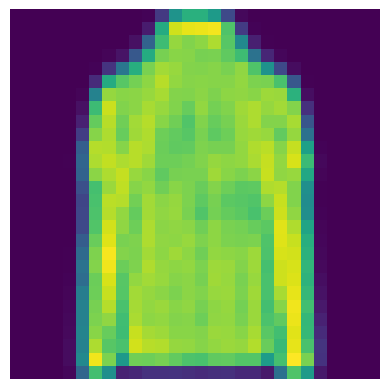

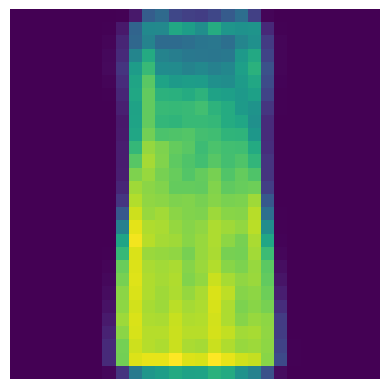

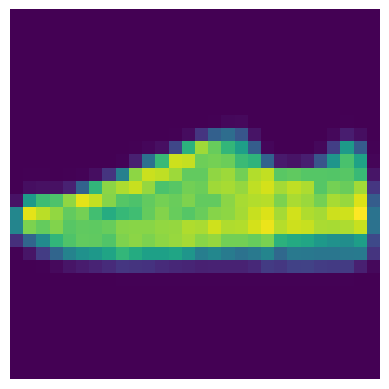

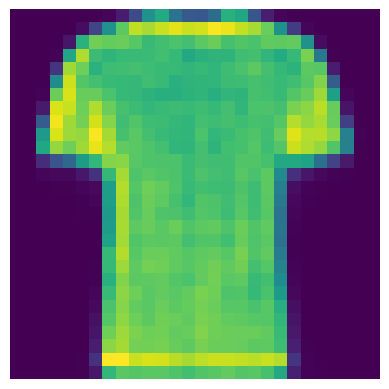

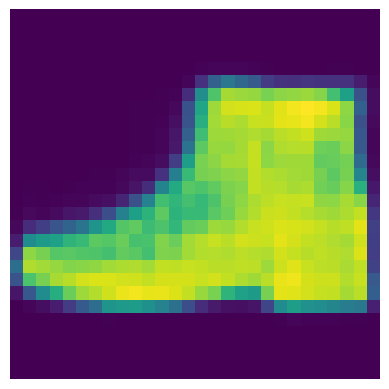

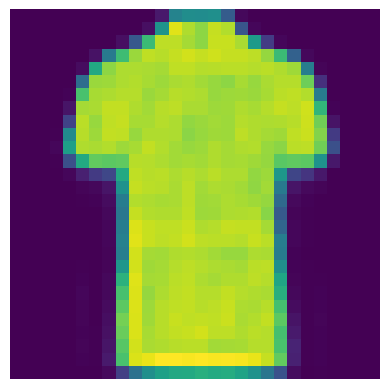

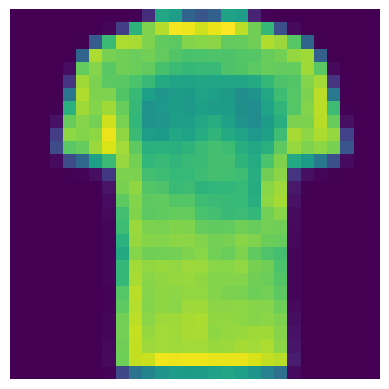

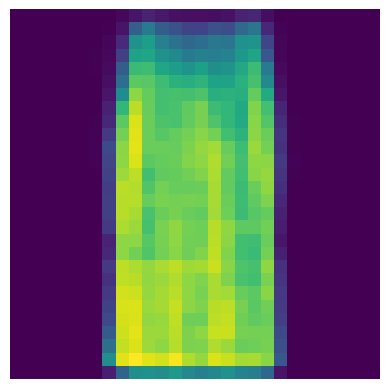

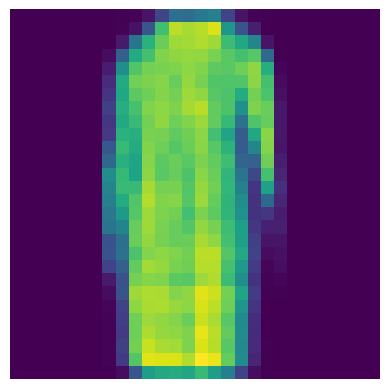

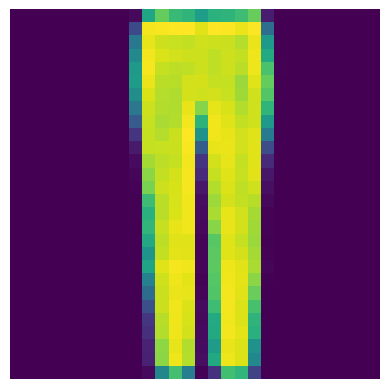

In [35]:
for i in range(10):
  show_image(x_recon, i)